# 4. Experiments

## 4.1 Performance and Stability

### 4.1.1 Setup

**Burgers configuration**

system,seed,n_states,n_controls,t1_initial,t1_max,nu,control_width,ic_modes,ic_scale,ic_basis
burgers,42,32,2,20.000000,60.000000,0.012000,0.200000,6,1.000000,sine


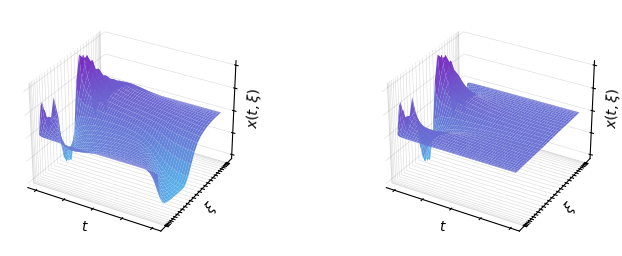

In [1]:
from experiments import create_config, figures
from IPython.display import display
import matplotlib.pyplot as plt

config = create_config(system="burgers", seed=42)
cache_dir = f"./cache_seed{config.seed}"
figures.save_config_table(config)
figures.show_spec(config, keys=figures.DEFAULT_CONFIG_KEYS, title="Burgers configuration")
fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### 4.1.2 Data Generation

In [2]:
from data import load_or_generate

n_trajectories = 500
n_candidates = 8 # perfect
n_MC = 1000 # 100 good

data_train, data_val, meta = load_or_generate(config, n_trajectories=n_trajectories, controller=config.ocp.LQR)
data = data_train  # Keep using 'data' for backward compatibility

summary_df = figures.save_data_summary_table(config, data)

display(summary_df.style.hide(axis="index"))

$N_{\mathrm{traj}}$,$|\mathcal{D}|$,t (max),|x| (mean),|x| (max),$\|x\|$ (mean),$\|x\|$ (max)
500,58799,5.014954,0.299107,2.164072,0.553647,1.362600


### 4.1.3 Training

Training 4 models on cpu...

--- Loading GradQRNet from cache ---

--- Loading GradQRNet (sup) from cache ---

--- Loading GradQRNet (pre) from cache ---

--- Loading GradQRNet (ad) from cache ---


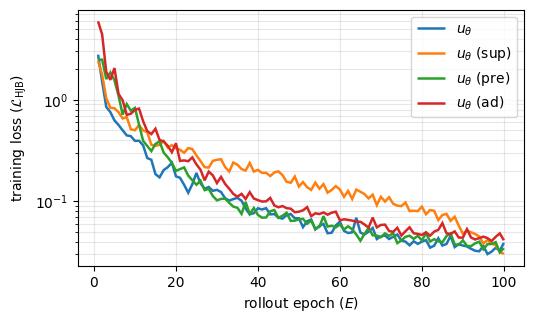

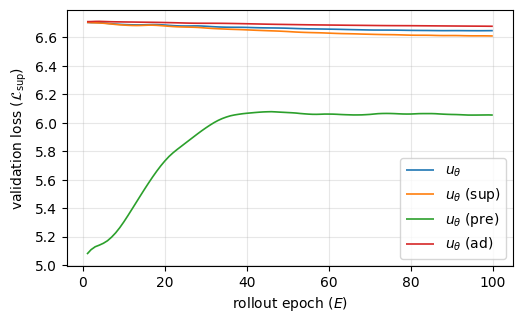

In [3]:
from controls.train import TrainConfig
from controls.model_factory import train_controllers

controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
}

cfg = TrainConfig(batch_size=16*int(config.n_states), n_candidates=n_candidates, horizon=25, dt_min=1e-3, rollouts=100, lambda_sup_base=1)

figures.save_params_table(cfg, "traincfg.tex", title="Training Configuration", config=config)

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
)
plt.show()

figures.plot_training_val_mse(
    config=config,
    histories=histories,
    controller_configs=controller_configs,
)
plt.show()



### 4.1.4 Results

In [4]:
from simulation import monte_carlo

controllers = [("LQR (Baseline)", config.ocp.LQR),] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
# Reuse these ICs for the combined-controller MC block below (same realizations).
burgers_mc_X0_pool = next(iter(results.values()))["X0_pool"]
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 1000/1000 [05:47<00:00,  2.88it/s]


,LQR (Baseline),GradQRNet,GradQRNet (sup),GradQRNet (pre),GradQRNet (ad)
Stability (S),74 ± 1%,79 ± 1%,79 ± 1%,78 ± 1%,82 ± 1%
Cost J (mean),0.60 ± 0.01,0.63 ± 0.02,0.64 ± 0.02,0.61 ± 0.01,0.67 ± 0.02


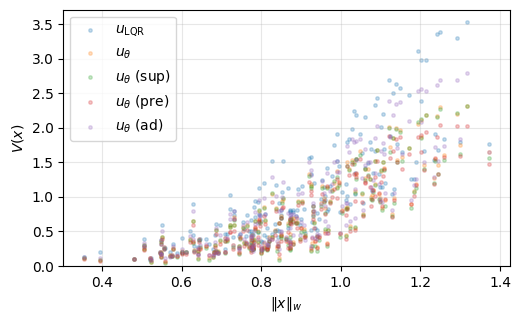

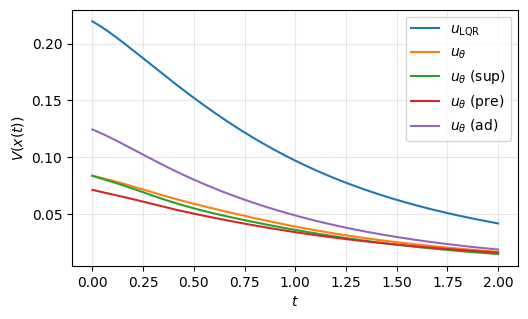

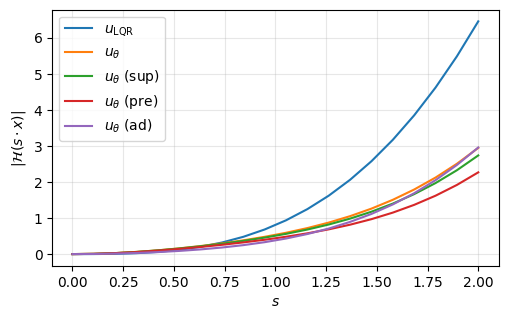

In [5]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
)
plt.show()

In [6]:
controller_configs = {
    "GradQRNet (sup/ad)": {"enabled": True}, # 512 candidates
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (pre/ad)": {"enabled": True},
    "GradQRNet (pre/sup/ad)": {"enabled": True},
}

In [7]:
trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,  # Use the config defined above
)

Training 4 models on cpu...

--- Loading GradQRNet (pre/sup) from cache ---

--- Loading GradQRNet (sup/ad) from cache ---

--- Loading GradQRNet (pre/ad) from cache ---

--- Loading GradQRNet (pre/sup/ad) from cache ---


In [8]:
controllers = [(name, trained_controllers[name]) for name in trained_controllers.keys()]

results = monte_carlo(
    config.ocp, config, controllers, n_MC=n_MC, X0_pool=burgers_mc_X0_pool
)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_combined.tex")

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [06:28<00:00,  2.58it/s]


,GradQRNet (pre/sup),GradQRNet (sup/ad),GradQRNet (pre/ad),GradQRNet (pre/sup/ad)
Stability (S),78 ± 1%,82 ± 1%,77 ± 1%,77 ± 1%
Cost J (mean),0.60 ± 0.01,0.67 ± 0.02,0.60 ± 0.01,0.61 ± 0.01


## 4.2 Generalization and Robustness

### 4.2.1 Setup

**Allen-Cahn configuration**

system,seed,n_states,n_controls,t1_initial,t1_max,nu,control_width,ic_modes,ic_scale,ic_basis
allen_cahn,42,32,1,10,30.000000,0.100000,0.400000,9,1.000000,cosine


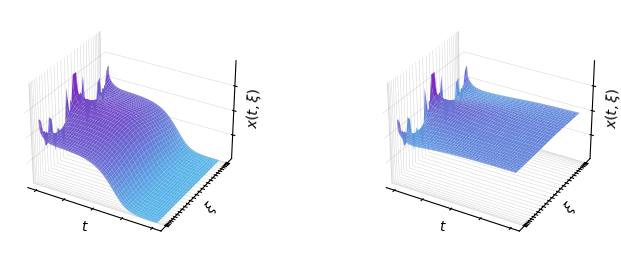

In [9]:
config = create_config(system="allen_cahn")
figures.save_config_table(config)
figures.show_spec(config, keys=figures.DEFAULT_CONFIG_KEYS, title="Allen-Cahn configuration")

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### 4.2.2 Data Generation

In [10]:
from data import load_or_generate

n_trajectories = 50
n_candidates = 50 # good 






data_ac_train, data_ac_val, meta_ac = load_or_generate(
    config, n_trajectories=n_trajectories, controller=config.ocp.LQR)

summary_ac = figures.save_data_summary_table(config, data_ac_train)
display(summary_ac.style.hide(axis="index"))

$N_{\mathrm{traj}}$,$|\mathcal{D}|$,t (max),|x| (mean),|x| (max),$\|x\|$ (mean),$\|x\|$ (max)
50,6932,8.579031,0.280646,1.687579,0.436766,1.080423


### 4.2.3 Training

In [11]:
controller_configs_ac = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
}

cfg_ac = TrainConfig(batch_size=16*int(config.n_states), rollouts=25, horizon=20, n_candidates=n_candidates, dt_min=5e-4, lambda_sup_base=10, unsup_lr=2e-4) # r=20, h=25

figures.save_params_table(cfg_ac, "allen_cahn_traincfg.tex", title="Training configuration", config=config)

figures.show_spec(
    cfg_ac, 
    keys=["sup_epochs", "sup_lr", "rollouts", "unsup_lr", "horizon", "batch_size"], 
    title="Training Configuration"
)


trained_models_ac, trained_controllers_ac, histories_ac = train_controllers(
    config=config,
    train_cfg=cfg_ac,
    data=data_ac_train,
    val_data=data_ac_val,
    controller_configs=controller_configs_ac,
)




**Training Configuration**

sup_epochs,sup_lr,rollouts,unsup_lr,horizon,batch_size
1,0.000100,25,0.000200,20,512


Training 4 models on cpu...

--- Loading GradQRNet from cache ---

--- Loading GradQRNet (sup) from cache ---

--- Loading GradQRNet (ad) from cache ---

--- Loading GradQRNet (sup/ad) from cache ---


### 4.2.4 Results

In [12]:
controllers = [("LQR (Baseline)", config.ocp.LQR)] + [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 1000/1000 [11:06<00:00,  1.50it/s]


,LQR (Baseline),GradQRNet,GradQRNet (sup),GradQRNet (ad),GradQRNet (sup/ad)
Stability (S),62 ± 2%,66 ± 2%,67 ± 1%,67 ± 1%,68 ± 1%
Cost J (mean),1.10 ± 0.06,1.06 ± 0.06,1.13 ± 0.07,1.05 ± 0.06,1.08 ± 0.06


In [13]:
results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC, dist=2.5, K=18)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_far.tex")

100%|██████████| 1000/1000 [18:25<00:00,  1.11s/it]


,LQR (Baseline),GradQRNet,GradQRNet (sup),GradQRNet (ad),GradQRNet (sup/ad)
Stability (S),18 ± 1%,19 ± 1%,20 ± 1%,20 ± 1%,20 ± 1%
Cost J (mean),1.76 ± 0.11,1.82 ± 0.13,1.90 ± 0.14,1.80 ± 0.12,1.97 ± 0.14


In [14]:
from simulation import monte_carlo_nu_mismatch

nu_baseline = config.ocp.nu
nu_eval = 0.095  # reduced diffusion
print(f"Model mismatch: train ν={nu_baseline}, eval ν={nu_eval}")
results = monte_carlo_nu_mismatch(
    config.ocp, config, controllers, nu_eval=nu_eval, n_MC=n_MC, verbose=0
)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(
    results, config=config, savepath="monte_carlo_nu_mismatch.tex"
)


Model mismatch: train ν=0.1, eval ν=0.095


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [13:54<00:00,  1.20it/s]


,LQR (Baseline),GradQRNet,GradQRNet (sup),GradQRNet (ad),GradQRNet (sup/ad)
Stability (S),45 ± 2%,49 ± 2%,50 ± 2%,52 ± 2%,54 ± 2%
Cost J (mean),0.81 ± 0.05,0.87 ± 0.05,0.87 ± 0.05,0.91 ± 0.05,0.99 ± 0.05


In [15]:
sigma_sde = 0.0005  # noise strength
dt_sde = 0.1  # Euler-Maruyama step

print(f"SDE Monte Carlo: σ={sigma_sde}, dt={dt_sde}, n_MC={n_MC}")
results = monte_carlo(
    config.ocp, config, controllers,
    n_MC=n_MC,
    sigma=sigma_sde, dt_sde=dt_sde, random_seed=42, verbose=1
)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(
    results, config=config, savepath="monte_carlo_sde.tex"
)


SDE Monte Carlo: σ=0.0005, dt=0.1, n_MC=1000

Evaluating LQR (Baseline)...


100%|██████████| 1000/1000 [01:42<00:00,  9.71it/s]



Evaluating GradQRNet...


100%|██████████| 1000/1000 [24:43<00:00,  1.48s/it]



Evaluating GradQRNet (sup)...


...


Evaluating GradQRNet (ad)...


100%|██████████| 1000/1000 [25:40<00:00,  1.54s/it]



Evaluating GradQRNet (sup/ad)...


100%|██████████| 1000/1000 [25:31<00:00,  1.53s/it]


,LQR (Baseline),GradQRNet,GradQRNet (sup),GradQRNet (ad),GradQRNet (sup/ad)
Stability (S),74 ± 1%,71 ± 1%,70 ± 1%,71 ± 1%,73 ± 1%
Cost J (mean),2.00 ± 0.11,1.52 ± 0.08,1.52 ± 0.09,1.57 ± 0.09,1.65 ± 0.10


## 4.3 Scalability to Data-Scarse Regimes

### 4.3.1 Setup

**Kuramoto-Sivashinsky configuration**

system,seed,n_states,n_controls,t1_initial,t1_max,nu,control_width,ic_modes,ic_scale,ic_basis
kuramoto_sivashinsky,42,96,4,5,20,0.255000,0.200000,3,2.500000,both


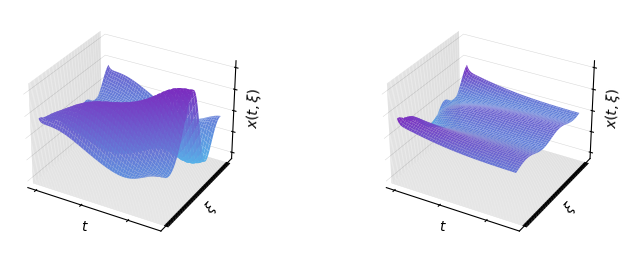

In [59]:
config = create_config(system="kuramoto_sivashinsky", nu=0.255, ic_scale=2.5, t1_initial=5, t1_max=20, ic_modes=3)

cache_dir = f"./cache_seed{config.seed}"
figures.save_config_table(config)
figures.show_spec(config, keys=figures.DEFAULT_CONFIG_KEYS, title="Kuramoto-Sivashinsky configuration")
fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

In [60]:
from simulation import monte_carlo

controllers = [("LQR (Baseline)", config.ocp.LQR)]# + [(name, trained_controllers[name]) for name in trained_controllers.keys()]
results = monte_carlo(config.ocp, config, controllers, n_MC=25)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 25/25 [00:05<00:00,  4.22it/s]


,LQR (Baseline)
Stability (S),72 ± 9%
Cost J (mean),45.04 ± 6.42


### 4.3.3 Training

**Training configuration**

sup_epochs,sup_lr,unsup_lr,horizon,batch_size,n_candidates,dt_min,dt_max
1,0.000100,0.000200,10,192,50,0.000000,1


Training 4 models on cpu...

--- Loading GradQRNet from cache ---

--- Loading GradQRNet (ad4) from cache ---

--- Loading GradQRNet (ad16) from cache ---

--- Loading GradQRNet (ad512) from cache ---


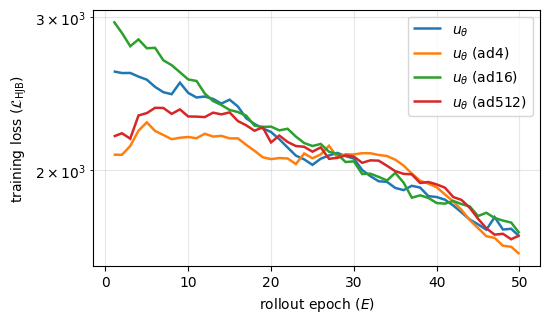

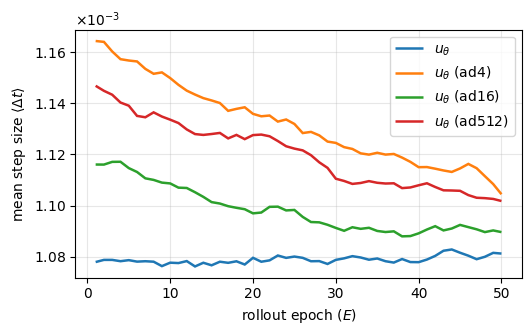

In [84]:


#ic scale = 0.25, dt_min=none worked, rollouts 50-100, unsup lr 1e-4
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (ad4)": {"enabled": True, "n_candidates": 4},
    "GradQRNet (ad16)": {"enabled": True, "n_candidates": 16},
    "GradQRNet (ad512)": {"enabled": True, "n_candidates": 512},
    #"GradQRNet (ad200)": {"enabled": True, "n_candidates": 200},
    #"GradQRNet (ad4000)": {"enabled": True, "n_candidates": 4000},
    #"GradQRNet (ad100)": {"enabled": True, "n_candidates": 100},
    #"GradQRNet (ad1000)": {"enabled": True, "n_candidates": 1000},
    #"GradQRNet (ad6)": {"enabled": True, "n_candidates": 6},
    #"GradQRNet (ad8)": {"enabled": True, "n_candidates": 8},

}

cfg_ks = TrainConfig(batch_size=2*int(config.n_states), n_candidates=n_candidates, horizon=10, dt_min=1e-7, rollouts=50, unsup_lr=2e-4, lambda_sup_base=1e3) # 25 rollouts workd


figures.save_params_table(
    cfg_ks,
    "traincfg.tex",
    title="Training Configuration",
    config=config,
    train_n_cand_tex=r"$\{1, 4, 16, 512\}$",
)

figures.show_spec(
    cfg_ks,
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "n_candidates", "dt_min", "dt_max"],
    title="Training configuration"
)

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg_ks,
    controller_configs=controller_configs,
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.1,
)
plt.show()

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    value_key="mean_dt",
    logy=False,
    ylabel=r"mean step size $\langle \Delta t \rangle$",
    plot_name="rollout_mean_dt",
    smooth="ema",
)
plt.show()



### 4.3.4 Results

In [86]:
controllers = [("LQR (Baseline)", config.ocp.LQR)] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]
results = monte_carlo(config.ocp, config, controllers, n_MC=250)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 250/250 [06:35<00:00,  1.58s/it]


,LQR (Baseline),GradQRNet,GradQRNet (ad4),GradQRNet (ad16),GradQRNet (ad512)
Stability (S),73 ± 3%,78 ± 3%,85 ± 2%,89 ± 2%,87 ± 2%
Cost J (mean),49.35 ± 1.82,49.60 ± 1.75,50.23 ± 1.69,49.54 ± 1.64,50.64 ± 1.67
